In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [2]:
X_broad = pd.read_csv("../../data/PDL1_experiment_3/X_broad_with_sample.csv").set_index("sample")
X_broad.info()

<class 'pandas.DataFrame'>
Index: 851 entries, SIDM00001 to SIDM01873
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AR      851 non-null    float64
 1   FOS     851 non-null    float64
 2   FOSL1   851 non-null    float64
 3   FOXO1   851 non-null    float64
 4   GATA2   851 non-null    float64
 5   IRF1    851 non-null    float64
 6   MYC     851 non-null    float64
 7   NFATC1  851 non-null    float64
 8   NFKB1   851 non-null    float64
 9   RELA    851 non-null    float64
 10  SOX2    851 non-null    float64
 11  SPI1    851 non-null    float64
 12  STAT1   851 non-null    float64
 13  STAT2   851 non-null    float64
 14  STAT3   851 non-null    float64
 15  STAT4   851 non-null    float64
 16  STAT6   851 non-null    float64
 17  TBX21   851 non-null    float64
dtypes: float64(18)
memory usage: 126.3+ KB


In [3]:
X_broad.describe()

,AR,FOS,FOSL1,FOXO1,GATA2,IRF1,MYC,NFATC1,NFKB1,RELA,SOX2,SPI1,STAT1,STAT2,STAT3,STAT4,STAT6,TBX21
count,851.000000,851.000000,851.000000,851.000000,851.000000,851.000000,851.000000,851.000000,851.000000,851.000000,851.000000,851.000000,851.000000,851.000000,851.000000,851.000000,851.000000,851.000000
mean,4.619577,210.550200,160.849694,11.379330,30.125817,18.245746,208.017156,4.241716,36.979401,48.363008,25.846639,15.338848,122.471774,44.026945,59.513666,2.305065,66.745981,0.965852
std,33.719829,351.132873,236.189393,15.888663,88.168102,18.561950,280.439694,7.422827,42.288282,17.611936,85.555684,56.306936,147.294698,32.234543,36.691961,6.954870,47.316586,8.182433
min,0.000000,0.390000,0.160000,0.030000,0.000000,0.800000,0.200000,0.000000,0.410000,9.110000,0.000000,0.000000,6.950000,6.740000,0.090000,0.000000,0.180000,0.000000
25%,0.000000,14.550000,6.360000,2.820000,2.025000,6.460000,65.235000,0.580000,20.835000,36.915000,0.070000,0.040000,50.855000,24.390000,36.220000,0.130000,35.920000,0.000000
50%,0.060000,80.090000,59.280000,6.130000,8.770000,12.670000,122.330000,2.050000,30.260000,46.760000,0.350000,0.100000,76.930000,35.330000,53.220000,0.470000,62.990000,0.030000
75%,1.895000,251.095000,219.390000,12.930000,22.625000,22.465000,231.805000,4.610000,43.385000,56.215000,9.350000,0.240000,127.945000,53.475000,73.245000,1.670000,90.725000,0.075000
max,909.880000,3586.540000,1886.900000,136.450000,1019.890000,119.720000,3906.590000,86.810000,1043.740000,146.530000,817.410000,489.760000,1113.500000,341.280000,427.330000,113.290000,352.270000,187.330000


In [4]:
X_broad.head()

,AR,FOS,FOSL1,FOXO1,GATA2,IRF1,MYC,NFATC1,NFKB1,RELA,SOX2,SPI1,STAT1,STAT2,STAT3,STAT4,STAT6,TBX21
sample,,,,,,,,,,,,,,,,,,
SIDM00001,0.03,17.34,3.76,24.80,0.07,29.66,288.91,13.55,118.44,45.80,0.37,42.81,355.81,70.54,80.92,9.72,110.55,57.95
SIDM00005,17.31,187.23,0.57,1.40,140.63,2.91,82.13,1.36,10.43,13.79,0.53,0.64,62.97,117.05,46.98,0.15,153.33,0.04
SIDM00008,0.03,5.78,299.86,10.93,0.23,12.25,105.08,0.95,32.01,55.01,42.48,0.03,53.95,21.97,59.07,1.67,42.99,0.00
SIDM00011,0.06,235.41,78.23,6.00,0.16,1.65,51.95,2.06,44.11,19.04,8.06,0.29,101.93,53.00,37.54,0.06,121.29,0.00
SIDM00015,0.03,3586.54,58.73,19.00,29.90,96.40,75.37,2.62,18.02,53.39,64.85,0.10,124.75,62.26,83.55,2.07,112.74,0.03


33.71982938774276


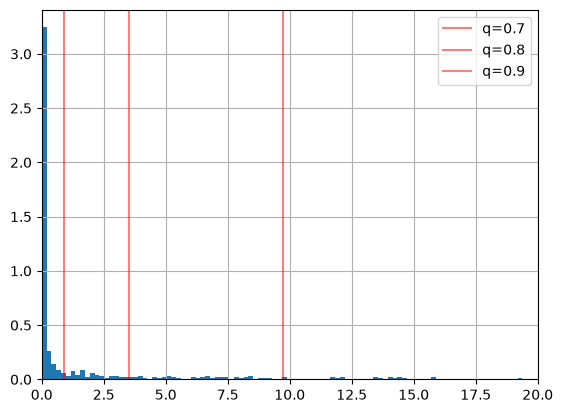

In [5]:
X_AR = X_broad["AR"]

ax = X_AR[X_AR < 20].hist(bins=100, density=True)
ax.set_xlim(X_AR.min(), 20)
ax.set_ylim(bottom=0)

quantiles = [0.7, 0.8, 0.9]
for q in quantiles:
    ax.axvline(X_AR.quantile(q), color="red", alpha=0.5, linestyle="-", label=f"q={q}")

ax.legend()
print(X_AR.std())

In [6]:
y_broad = pd.read_csv("../../data/PDL1_experiment_3/y_broad.csv")["CD274"]
y_broad.info()

<class 'pandas.Series'>
RangeIndex: 851 entries, 0 to 850
Series name: CD274
Non-Null Count  Dtype  
--------------  -----  
851 non-null    float64
dtypes: float64(1)
memory usage: 6.8 KB


In [7]:
y_broad.describe()

count    851.000000
mean      13.035840
std       33.111015
min        0.000000
25%        0.605000
50%        2.220000
75%       10.905000
max      453.220000
Name: CD274, dtype: float64

In [8]:
y_broad.head()

0    17.34
1     1.78
2    18.98
3     2.63
4     4.04
Name: CD274, dtype: float64

33.11101493770643


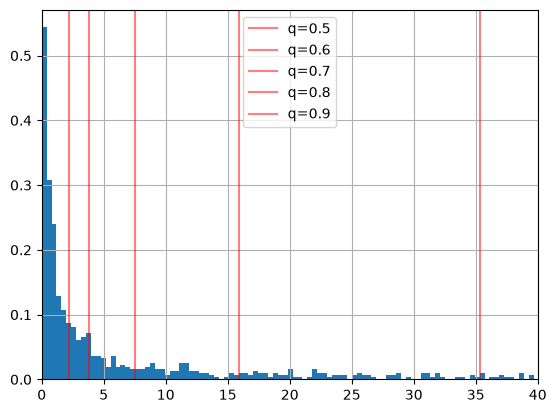

In [9]:
ax = y_broad[y_broad < 40].hist(bins=100, density=True)
ax.set_xlim(y_broad.min(), 40)
ax.set_ylim(bottom=0)

quantiles = [0.5, 0.6, 0.7, 0.8, 0.9]
for q in quantiles:
    ax.axvline(y_broad.quantile(q), color="red", alpha=0.5, linestyle="-", label=f"q={q}")

ax.legend()
print(y_broad.std())

In [10]:
y_broad = pd.read_csv("../../data/Y_PDL1expression_Broad.csv").set_index("sample")
y_broad.head()

,PDL1 expression
sample,
SIDM00001,-0.050474
SIDM00005,-0.248723
SIDM00008,-0.052154
SIDM00011,-0.230074
SIDM00015,-0.212937


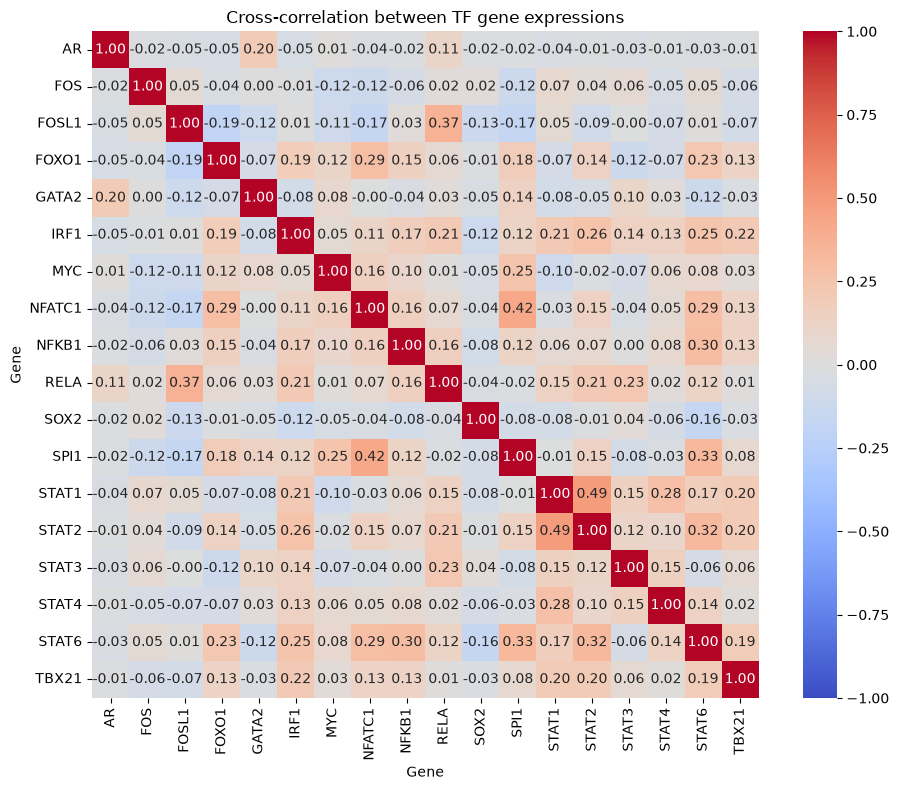

In [11]:
from tex import tex_gen_file

corr = X_broad.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Cross-correlation between TF gene expressions")
ax.set_xlabel("Gene")
ax.set_ylabel("Gene")
plt.tight_layout()
plt.savefig(tex_gen_file(f"data/fig_corr_TPM.svg", root="../../"), bbox_inches="tight")
plt.show()

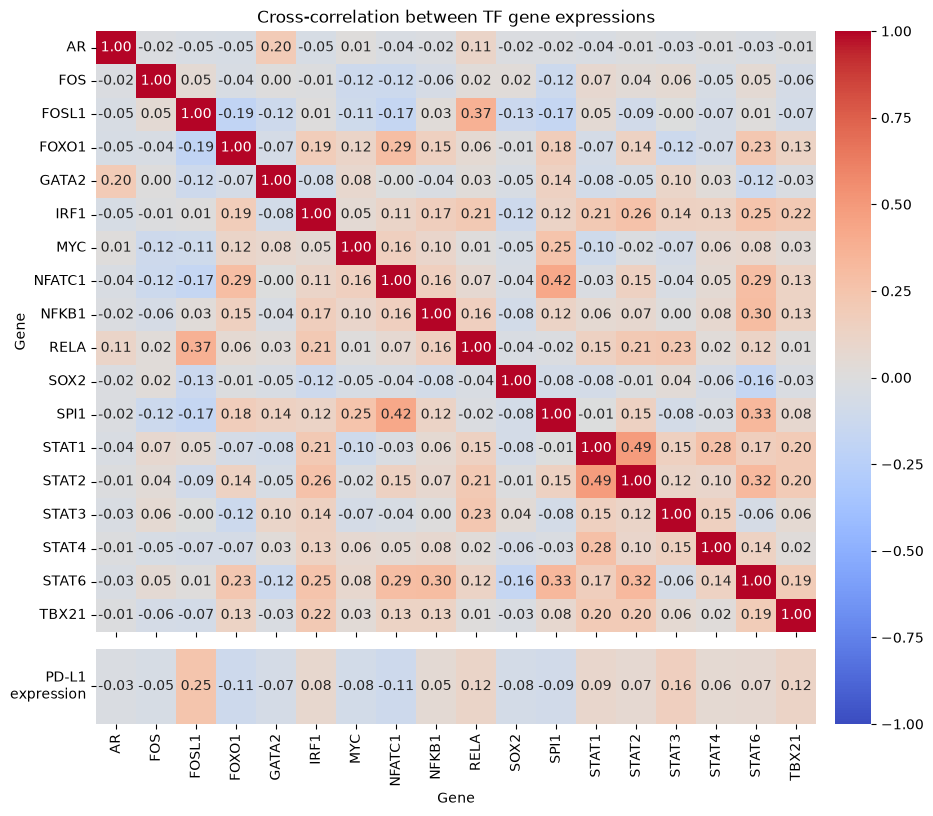

In [12]:
common = X_broad.index.intersection(y_broad.index)
pdl1_corr = X_broad.loc[common].corrwith(y_broad.loc[common, "PDL1 expression"])
pdl1_corr = pdl1_corr.reindex(corr.columns)

fig = plt.figure(figsize=(10, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[8, 1], width_ratios=[20, 1],
                       hspace=0.05, wspace=0.05)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
cax = fig.add_subplot(gs[:, 1])

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax1, cbar_ax=cax)
ax1.set_title("Cross-correlation between TF gene expressions")
ax1.set_ylabel("Gene")
ax1.set_xlabel("")
ax1.tick_params(axis="x", labelbottom=False)

sns.heatmap(pdl1_corr.to_frame().T, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax2, cbar=False,
            yticklabels=["PD-L1\nexpression"])
ax2.set_xlabel("Gene")
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

plt.savefig(tex_gen_file("data/fig_corr_TPM_extra.svg", root="../../"), bbox_inches="tight")
plt.show()